# Week 7: Classifiers

This notebook applies classification models to predict emotion from extracted audio features. We compare our MiniLearn implementations against scikit-learn as a reference.

## Logistic Regression

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sys
sys.path.insert(0, str(Path.cwd().parent))
from minilearn.classifiers.decision_tree import DecisionTreeClassifier as MLDecisionTreeClassifier
from minilearn.classifiers.logistic import LogisticRegression as MLLogisticRegression
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier

In [2]:
# Resolve project root from notebook location
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'SER_Project').exists():
    PROJECT_ROOT = NOTEBOOK_DIR / 'SER_Project'
elif NOTEBOOK_DIR.name == 'notebooks' and (NOTEBOOK_DIR.parent / 'pipeline').exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / 'data'
FEATURES_CSV = DATA_DIR / 'features.csv'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FEATURES_CSV exists: {FEATURES_CSV.exists()}')

PROJECT_ROOT: c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project
FEATURES_CSV exists: True


In [3]:
if not FEATURES_CSV.exists():
    raise FileNotFoundError(
        f'Missing {FEATURES_CSV}. Run the feature extraction pipeline first (notebook 01 or CLI).'
    )

df = pd.read_csv(FEATURES_CSV)
print(f'Feature table shape: {df.shape}')
print(f'Emotions: {sorted(df["emotion"].unique())}')
print(f'\nEmotion distribution:\n{df["emotion"].value_counts().sort_index()}')

Feature table shape: (1440, 384)
Emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

Emotion distribution:
emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


In [4]:
# Prepare data for classification
target_col = 'emotion'
if target_col not in df.columns:
    raise KeyError(f'Expected target column {target_col} in features.csv')

drop_cols = [
    'filepath', 'filename',
    'modality', 'vocal_channel', 'emotion', 'intensity', 'statement',
    'modality_code', 'vocal_channel_code', 'emotion_code', 'statement_code',
    'intensity_code', 'repetition', 'actor_id',
]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features: {X.shape[1]}')
print(f'Rows: {X.shape[0]}')
print(f'Classes: {y.nunique()}')

Features: 370
Rows: 1440
Classes: 8


In [5]:
# Train/test split with stratification to preserve emotion distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Standardize features (fit on training data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set: {X_test_scaled.shape}')

Training set: (1152, 370)
Test set: (288, 370)


In [6]:
# MiniLearn Logistic Regression
ml_lr = MLLogisticRegression(
    learning_rate=0.01,
    max_iter=500,
    fit_intercept=True,
    l2_penalty=0.0001,
    random_state=42,
    verbose=False,
)
ml_lr.fit(X_train_scaled, y_train)
ml_y_pred = ml_lr.predict(X_test_scaled)

print('MiniLearn LogisticRegression fitted.')
print(f'Accuracy: {ml_lr.score(X_test_scaled, y_test):.4f}')

MiniLearn LogisticRegression fitted.
Accuracy: 0.6042


In [7]:
# Scikit-learn Logistic Regression (for comparison)
sk_lr = SKLogisticRegression(
    max_iter=500,
    penalty='l2',
    C=1e4,  # inverse of l2_penalty
    random_state=42,
    solver='lbfgs',
)
sk_lr.fit(X_train_scaled, y_train)
sk_y_pred = sk_lr.predict(X_test_scaled)

print('Scikit-learn LogisticRegression fitted.')
print(f'Accuracy: {sk_lr.score(X_test_scaled, y_test):.4f}')

c:\Users\wblut\Documents\My Projects\Python\CSE 432\Project_CSE432-532\SER_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Scikit-learn LogisticRegression fitted.
Accuracy: 0.6597


In [8]:
# Compute metrics for both models
def compute_metrics(y_true, y_pred, model_name):
    """Compute classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision (macro)': prec_macro,
        'Recall (macro)': recall_macro,
        'F1 (macro)': f1_macro,
    }

metrics_ml = compute_metrics(y_test, ml_y_pred, 'MiniLearn LR')
metrics_sk = compute_metrics(y_test, sk_y_pred, 'Scikit-learn LR')

results_df = pd.DataFrame([metrics_ml, metrics_sk])
print(results_df.to_string(index=False))

          Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn LR  0.604167           0.599567        0.582827    0.578895
Scikit-learn LR  0.659722           0.678377        0.654521    0.661803


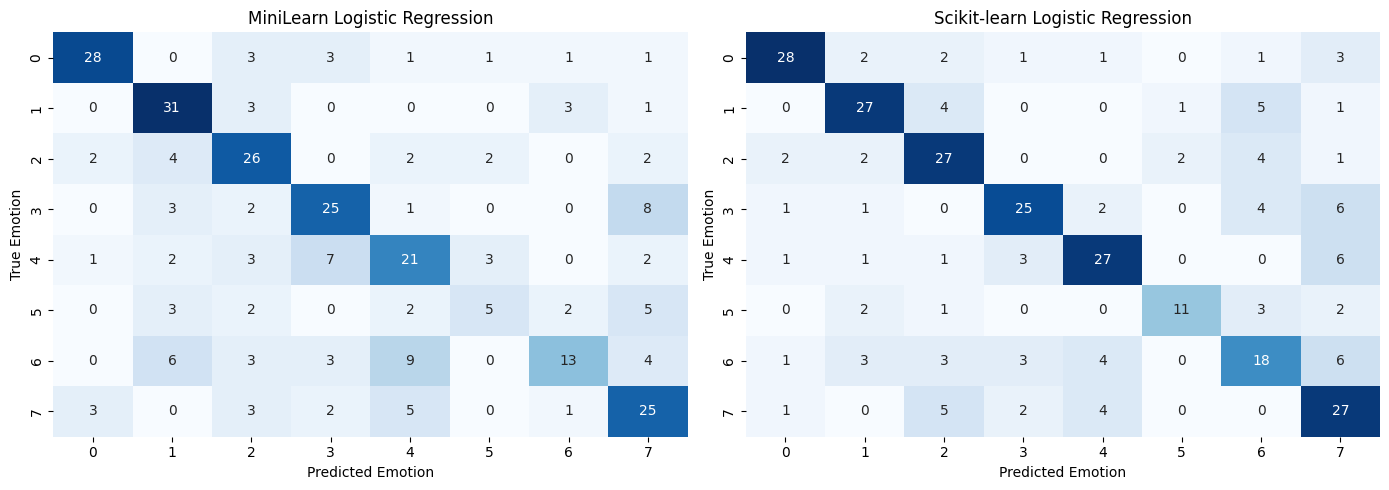

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ml = confusion_matrix(y_test, ml_y_pred, labels=sorted(y_test.unique()))
cm_sk = confusion_matrix(y_test, sk_y_pred, labels=sorted(y_test.unique()))

sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Logistic Regression')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Logistic Regression')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Logistic Regression Summary

Both implementations show similar performance on the SER classification task. The confusion matrices reveal which emotions are confused with one another and can guide feature engineering or model tuning in later weeks.

## Decision Tree

In [17]:
# MiniLearn Decision Tree
ml_dt = MLDecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
)
ml_dt.fit(X_train.values, y_train.values)
ml_dt_y_pred = ml_dt.predict(X_test.values)

print('MiniLearn DecisionTreeClassifier fitted.')
print(f'Accuracy: {ml_dt.score(X_test.values, y_test.values):.4f}')

MiniLearn DecisionTreeClassifier fitted.
Accuracy: 0.3785


In [ ]:
# Scikit-learn Decision Tree (for comparison)
sk_dt = SKDecisionTreeClassifier(
    max_depth=6,
    min_samples_split=4,
    min_samples_leaf=2,
    ccp_alpha=0.0,
    random_state=42,
)
sk_dt.fit(X_train, y_train)
sk_dt_y_pred = sk_dt.predict(X_test)

print('Scikit-learn DecisionTreeClassifier fitted.')
print(f'Accuracy: {sk_dt.score(X_test, y_test):.4f}')

Scikit-learn DecisionTreeClassifier fitted.
Accuracy: 0.3681


          Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
   MiniLearn DT  0.378472           0.365758        0.371879    0.364935
Scikit-learn DT  0.368056           0.348794        0.362264    0.351461


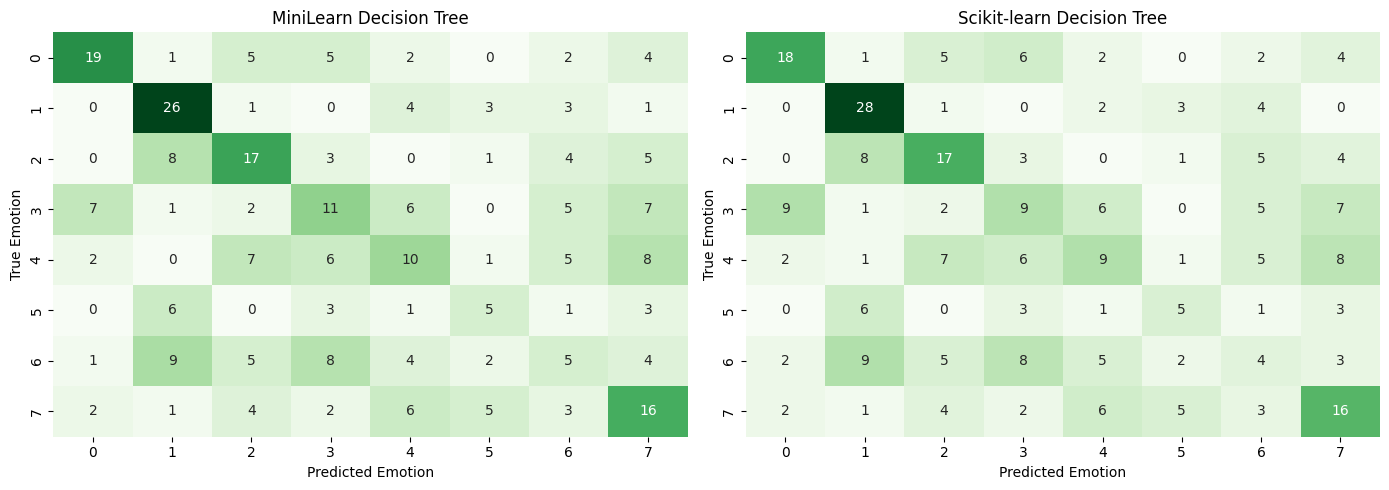

In [19]:
# Decision Tree metrics
metrics_dt_ml = compute_metrics(y_test, ml_dt_y_pred, 'MiniLearn DT')
metrics_dt_sk = compute_metrics(y_test, sk_dt_y_pred, 'Scikit-learn DT')

results_dt_df = pd.DataFrame([metrics_dt_ml, metrics_dt_sk])
print(results_dt_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt_ml = confusion_matrix(y_test, ml_dt_y_pred, labels=sorted(y_test.unique()))
cm_dt_sk = confusion_matrix(y_test, sk_dt_y_pred, labels=sorted(y_test.unique()))

sns.heatmap(cm_dt_ml, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False)
axes[0].set_title('MiniLearn Decision Tree')
axes[0].set_ylabel('True Emotion')
axes[0].set_xlabel('Predicted Emotion')

sns.heatmap(cm_dt_sk, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Scikit-learn Decision Tree')
axes[1].set_ylabel('True Emotion')
axes[1].set_xlabel('Predicted Emotion')

plt.tight_layout()
plt.show()

## Decision Tree Summary

MiniLearn and scikit-learn decision trees are compared above. The scikit-learn model is constructed with `ccp_alpha=0.0` (no post-pruning). Increasing `ccp_alpha` will prune the tree and can help reduce overfitting; try values such as 0.001 or 0.01 and re-evaluate.

Use the printed metrics and confusion matrices to compare Accuracy, Precision, Recall, and F1 for each implementation. The MiniLearn tree is a lightweight reference implementation; use scikit-learn's implementation and `ccp_alpha` tuning for production experiments or further hyperparameter search.

## k-Nearest-Numbers

## k-Nearest-Numbers Summary

## Naive Bayes

## Naive Bayes Summary